## 机构抱团效应与荐股收益研究

### 1.研究概述
本研究围绕"机构是否存在抱团效应、以及这种抱团行为能否为投资者带来超额收益"这一核心问题展开。

### 2.研究对象
从中信建投、华泰证券（头部）、招商证券、平安证券（腰部）、天风证券、开源证券（尾部）六家券商的月度金股推荐数据中，筛选出被所有机构累计推荐次数最多的 Top10 只股票（抱团股）和推荐次数最少的 Bottom10 只股票（冷门股），共计 20 只股票，覆盖 2025 年 4 月至 2026 年 4 月共 13 个月。

### 3.数据来源
六大券商月度金股推荐明细（原始数据）+ yfinance 历史行情数据（月涨跌幅）+ 上证指数作为大盘基准。

### 4.核心发现
1. 抱团股（Top10）13 个月累计收益约 54.5%，冷门股（Bottom10）约 25%，上证指数约 14%——抱团股在研究期内大幅跑赢大盘和冷门股
2. Top10 在大多数月份跑赢上证指数，Alpha（超额收益）整体为正；但在市场整体下跌时（如 2026 年 3 月）同样出现大幅回撤
3. 结论：机构扎堆推荐的热门股在研究期内确实带来了显著超额收益，支持"抱团效应存在"的假说；但这种超额收益不稳定，不能简单外推到所有市场周期

## 一、数据分析
### 步骤一：读取原始数据


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# 解决中文乱码
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [268]:
df = pd.read_excel(
    r'D:\小组作业\维度二\六大券商合并数据.xlsx',
    sheet_name='合并数据'
)

print(f"数据规模：{len(df)} 条记录，共 {df['证券代码'].nunique()} 只不同的股票")
print(f"时间范围：{df['推荐月份'].min()} 至 {df['推荐月份'].max()}")

数据规模：889 条记录，共 346 只不同的股票
时间范围：2025-04-30 至 2026-04-30


在六大券商2025年4月-2026年4月这个时间段内，共有346支不同的股票被推荐


统计每只股票在 13 个月内被所有机构推荐的总次数，作为划分"抱团股"和"冷门股"的核心依据。

In [269]:
rec_count = df.groupby('证券代码').size().reset_index(name='累计推荐次数')

print(f"共有 {len(rec_count)} 只不同的股票被推荐过")
print(f"\n推荐次数分布统计：")
print(rec_count['累计推荐次数'].describe())

共有 346 只不同的股票被推荐过

推荐次数分布统计：
count    346.000000
mean       2.569364
std        2.995085
min        1.000000
25%        1.000000
50%        1.000000
75%        3.000000
max       28.000000
Name: 累计推荐次数, dtype: float64


 6 家券商在统计周期内，所有被推荐过的不同股票数量共346支，平均每只股票被推荐约 2.57 次，至少 75% 的股票，推荐次数≤3 次；前 50% 的股票都只被推了 1 次，最多的一支股票被推了28次。

In [270]:
def to_yf_code(code):
    """
    将原始代码转换为 yfinance 格式
    '600019.SH' -> '600019.SS'（上海）
    '000651.SZ' -> '000651.SZ'（深圳，无需改）
    '688041.SH' -> '688041.SS'（科创板也用 .SS）
    """
    if code.endswith('.SH'):
        return code.replace('.SH', '.SS')
    return code  # .SZ 结尾直接用

### 步骤二：数据处理

In [271]:
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
import os
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 新建 data 文件夹
data_dir = r'D:\小组作业\维度二\data'
os.makedirs(data_dir, exist_ok=True)

# 读取数据
df = pd.read_excel(
    r'D:\小组作业\维度二\六大券商合并数据.xlsx',
    sheet_name='合并数据'
)

# 计算累计推荐次数
rec_count = df.groupby('证券代码').size().reset_index(name='累计推荐次数')

# 分类
top10_codes = rec_count.nlargest(10, '累计推荐次数')['证券代码'].tolist()
bottom_candidates = rec_count[rec_count['累计推荐次数'] >= 2]
bottom10_codes = bottom_candidates.nsmallest(10, '累计推荐次数')['证券代码'].tolist()

# 构建展示表（含股票简称和累计次数）
top10_df = rec_count[rec_count['证券代码'].isin(top10_codes)].copy()
top10_df = top10_df.merge(
    df[['证券代码', '证券简称']].drop_duplicates(),
    on='证券代码', how='left'
)
top10_df['分组'] = 'Top10（抱团）'
top10_df = top10_df.sort_values('累计推荐次数', ascending=False).reset_index(drop=True)

bottom10_df = rec_count[rec_count['证券代码'].isin(bottom10_codes)].copy()
bottom10_df = bottom10_df.merge(
    df[['证券代码', '证券简称']].drop_duplicates(),
    on='证券代码', how='left'
)
bottom10_df['分组'] = 'Bottom10（冷门）'
bottom10_df = bottom10_df.sort_values('累计推荐次数', ascending=True).reset_index(drop=True)

# 保存 CSV
top10_df.to_csv(f'{data_dir}\\top10_抱团股列表.csv', index=False, encoding='utf-8-sig')
bottom10_df.to_csv(f'{data_dir}\\bottom10_冷门股列表.csv', index=False, encoding='utf-8-sig')

print("=" * 60)
print("【Top10 抱团股】")
print("=" * 60)
for _, row in top10_df.iterrows():
    print(f"  {row['证券代码']}  {row['证券简称']}  |  累计推荐 {row['累计推荐次数']} 次")
print("\n✅ 已保存：top10_抱团股列表.csv")

print()
print("=" * 60)
print("【Bottom10 冷门股】")
print("=" * 60)
for _, row in bottom10_df.iterrows():
    print(f"  {row['证券代码']}  {row['证券简称']}  |  累计推荐 {row['累计推荐次数']} 次")
print("\n✅ 已保存：bottom10_冷门股列表.csv")

【Top10 抱团股】
  300308.SZ  中际旭创  |  累计推荐 28 次
  688041.SH  海光信息  |  累计推荐 19 次
  002475.SZ  立讯精密  |  累计推荐 17 次
  601899.SH  紫金矿业  |  累计推荐 17 次
  688235.SH  百济神州  |  累计推荐 17 次
  300502.SZ  新易盛  |  累计推荐 16 次
  300454.SZ  深信服  |  累计推荐 14 次
  600183.SH  生益科技  |  累计推荐 11 次
  600258.SH  首旅酒店  |  累计推荐 11 次
  603993.SH  洛阳钼业  |  累计推荐 11 次

✅ 已保存：top10_抱团股列表.csv

【Bottom10 冷门股】
  000063.SZ  中兴通讯  |  累计推荐 2 次
  000333.SZ  美的集团  |  累计推荐 2 次
  000426.SZ  兴业银锡  |  累计推荐 2 次
  000568.SZ  泸州老窖  |  累计推荐 2 次
  000582.SZ  北部湾港  |  累计推荐 2 次
  000596.SZ  古井贡酒  |  累计推荐 2 次
  000690.SZ  宝新能源  |  累计推荐 2 次
  000729.SZ  燕京啤酒  |  累计推荐 2 次
  000791.SZ  甘肃能源  |  累计推荐 2 次
  000792.SZ  盐湖股份  |  累计推荐 2 次

✅ 已保存：bottom10_冷门股列表.csv


本步骤通过读取原始数据、计算每只股票的累计推荐次数，划分 Top10（抱团股）和 Bottom10（冷门股）。本次研究冷门股设置了"至少被推荐 2 次"的门槛，是为了排除只被推过 1 次的极端冷门股，确保 Bottom10 也是机构在认真研究后选择的标的，避免极端值干扰对比结论。最后识别出热门股、冷门股，以csv格式导出。

### 步骤三：爬取上证指数月线数据作为大盘基准

In [272]:
def to_yf_code(code):
    """
    '600019.SH' -> '600019.SS'（上海 / 科创板）
    '000651.SZ' -> '000651.SZ'（深圳，直接用）
    """
    if code.endswith('.SH'):
        return code.replace('.SH', '.SS')
    return code

In [273]:
def fetch_index_monthly(start='2025-03-01', end='2026-05-31'):
    try:
        ticker = yf.Ticker('000001.SS')
        hist = ticker.history(start=start, end=end, interval='1mo')
        if hist.empty or len(hist) < 2:
            return None
        hist = hist.reset_index()
        hist['上证月涨跌幅'] = hist['Close'].pct_change() * 100
        hist['月份'] = hist['Date'].dt.strftime('%Y-%m')
        return hist[['月份', '上证月涨跌幅']].dropna()
    except Exception as e:
        print(f"  上证指数拉取失败: {e}")
        return None

print("正在拉取上证指数月线数据...")
index_df = fetch_index_monthly()
index_df.to_csv(f'{data_dir}\\上证指数月线数据.csv', index=False, encoding='utf-8-sig')
print(f"上证指数数据拉取完成，共 {len(index_df)} 个月，已保存")
print(index_df.head())

正在拉取上证指数月线数据...
上证指数数据拉取完成，共 14 个月，已保存
        月份    上证月涨跌幅
1  2025-04 -1.700222
2  2025-05  2.087692
3  2025-06  2.895873
4  2025-07  3.738852
5  2025-08  7.968162


利用yfinance获得此事件范围内上证月涨跌幅数据，用于后续研究

### 步骤四：批量爬取 Top10 和 Bottom10 的个股月线数据

In [274]:

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 200)
def fetch_stock_monthly(code_yf, code_orig, start='2025-03-01', end='2026-05-31'):
    try:
        ticker = yf.Ticker(code_yf)
        hist = ticker.history(start=start, end=end, interval='1mo')
        if hist.empty or len(hist) < 2:
            return None
        hist = hist.reset_index()
        hist['月涨跌幅'] = hist['Close'].pct_change() * 100
        hist['月份'] = hist['Date'].dt.strftime('%Y-%m')
        hist['股票代码'] = code_orig
        return hist[['月份', '月涨跌幅', '股票代码']]
    except Exception as e:
        print(f"  拉取失败 {code_orig}: {e}")
        return None


all_codes = list(set(top10_codes + bottom10_codes))
yf_map = {c: to_yf_code(c) for c in all_codes}

print(f"共需爬取 {len(all_codes)} 只股票...")

all_monthly_data = []
for code in tqdm(all_codes, desc='从 yfinance 爬取月线数据'):
    result = fetch_stock_monthly(yf_map[code], code)
    if result is not None:
        all_monthly_data.append(result)
    import time; time.sleep(0.2)

price_df = pd.concat(all_monthly_data, ignore_index=True).dropna(subset=['月涨跌幅'])
price_df.to_csv(f'{data_dir}\\top10_bottom10_月线数据.csv', index=False, encoding='utf-8-sig')
print(f"\n股票月线数据爬取完成，共 {len(price_df)} 条记录，已保存")
print(f"涉及股票数：{price_df['股票代码'].nunique()}")

共需爬取 20 只股票...


从 yfinance 爬取月线数据: 100%|██████████| 20/20 [00:06<00:00,  3.11it/s]


股票月线数据爬取完成，共 280 条记录，已保存
涉及股票数：20


获取 20 只股票在研究期内的每月涨跌幅数据，作为计算个股收益和超额收益的原始依据

### 步骤五：数据清洗
剔除原始数据中的空值和完全重复记录，确保后续分析基于干净、一致的数据集。

In [275]:
print("=" * 60)
print("【数据清洗】")
print("=" * 60)

n_before = len(df)

# 1. 删除证券代码为空的记录
df = df.dropna(subset=['证券代码'])
print(f"1. 删除证券代码为空的记录：{n_before - len(df)} 条")


# 2. 删除完全重复的行
n_before_dup = len(df)
df = df.drop_duplicates(subset=['机构名称', '推荐月份', '证券代码'])
print(f"3. 删除完全重复的行：{n_before_dup - len(df)} 条")

print(f"\n清洗后总记录：{len(df)} 条")

【数据清洗】
1. 删除证券代码为空的记录：0 条
3. 删除完全重复的行：0 条

清洗后总记录：889 条


### 步骤六：将收益数据匹配回原始推荐记录
把爬取的个股月涨跌幅和上证指数月涨跌幅，通过"证券代码 + 月份"两个字段，合并到原始推荐记录中，形成可计算收益对比的完整数据表。

In [276]:
df['月份'] = pd.to_datetime(df['推荐月份']).dt.strftime('%Y-%m')

df['分组'] = '其他'
df.loc[df['证券代码'].isin(top10_codes), '分组'] = 'Top10（抱团）'
df.loc[df['证券代码'].isin(bottom10_codes), '分组'] = 'Bottom10（冷门）'

df = df.merge(
    price_df[['月份', '月涨跌幅', '股票代码']],
    left_on=['证券代码', '月份'],
    right_on=['股票代码', '月份'],
    how='left',
    suffixes=('', '_yf')
)
df.drop(columns=['股票代码'], inplace=True, errors='ignore')

df = df.merge(index_df, on='月份', how='left')

df_top    = df[df['分组'] == 'Top10（抱团）'].copy()
df_bottom = df[df['分组'] == 'Bottom10（冷门）'].copy()

print("=" * 55)
print("【数据匹配结果】")
print("=" * 55)
print(f"Top10    原始记录 {len(df_top)} 条，匹配到收益 {df_top['月涨跌幅'].notna().sum()} 条，匹配率 {df_top['月涨跌幅'].notna().mean():.1%}")
print(f"Bottom10 原始记录 {len(df_bottom)} 条，匹配到收益 {df_bottom['月涨跌幅'].notna().sum()} 条，匹配率 {df_bottom['月涨跌幅'].notna().mean():.1%}")
print(f"上证指数  匹配率：{df['上证月涨跌幅'].notna().mean():.1%}")

【数据匹配结果】
Top10    原始记录 161 条，匹配到收益 161 条，匹配率 100.0%
Bottom10 原始记录 20 条，匹配到收益 20 条，匹配率 100.0%
上证指数  匹配率：100.0%


### 步骤七：按月汇总，计算超额收益
对每个月份分别计算 Top10 组和 Bottom10 组的平均月收益，并通过与上证指数相减，得到两组各自的超额收益（Alpha），构建可对比的月度收益表

In [277]:
top_monthly    = df_top.groupby('月份')['月涨跌幅'].mean()
bottom_monthly = df_bottom.groupby('月份')['月涨跌幅'].mean()

comparison = pd.DataFrame({
    'Top10月均收益(%)':    top_monthly,
    'Bottom10月均收益(%)': bottom_monthly
}).dropna()

comparison = comparison.reset_index().merge(index_df, on='月份', how='left')
comparison = comparison.set_index('月份').sort_index()

comparison['Top10 Alpha(%)']    = comparison['Top10月均收益(%)']    - comparison['上证月涨跌幅']
comparison['Bottom10 Alpha(%)'] = comparison['Bottom10月均收益(%)'] - comparison['上证月涨跌幅']
comparison['超额(Top-Bottom)(%)'] = comparison['Top10月均收益(%)']    - comparison['Bottom10月均收益(%)']

comparison.to_csv(f'{data_dir}\\top10_vs_bottom10_月度对比.csv', encoding='utf-8-sig')

print("=" * 70)
print("【月度收益对比表（含上证指数基准）】")
print("=" * 70)
print(comparison.round(2).to_string())
print("\n✅ 已保存：top10_vs_bottom10_月度对比.csv")

【月度收益对比表（含上证指数基准）】
         Top10月均收益(%)  Bottom10月均收益(%)  上证月涨跌幅  Top10 Alpha(%)  Bottom10 Alpha(%)  超额(Top-Bottom)(%)
月份                                                                                                  
2025-05          0.10             2.63    2.09           -1.99               0.54              -2.53
2025-06         10.34            -2.30    2.90            7.44              -5.20              12.64
2025-09         11.65             0.16    0.64           11.00              -0.49              11.49
2025-10          2.19            -3.28    1.85            0.34              -5.14               5.47
2025-12         10.72            -8.09    2.06            8.66             -10.15              18.81
2026-01          7.97            16.41    3.76            4.21              12.65              -8.44
2026-02         -7.89            16.67    1.09           -8.98              15.58             -24.56
2026-03        -13.14            -3.04   -6.51           -6.63          

### 小结
在整个观察期内（2025年5月至2026年4月），抱团股整体收益显著高于冷门股，支持"机构抱团推热门股带来超额收益"的假说。但 2026 年初的反转说明这种超额收益不稳定——当市场风格切换时，抱团股可能快速跑输，且回撤幅度往往更大。

### 步骤八：总体统计
 汇总 13 个月的各项统计指标，包括各组的算术平均收益、波动性（标准差）、正收益月份数、最大/最小月收益，以及相对上证指数的超额收益和跑赢大盘的月份占比，从整体上描述两组的表现差异。

In [278]:
def stats(series, label):
    valid = series.dropna()
    print(f"\n▶ {label}")
    print(f"  算术平均月收益：{valid.mean():.2f}%")
    print(f"  收益标准差（波动性）：{valid.std():.2f}%")
    print(f"  正收益月份数：{(valid > 0).sum()} / {len(valid)} 个月")
    print(f"  最大月收益：{valid.max():.2f}%")
    print(f"  最小月收益：{valid.min():.2f}%")

stats(df_top['月涨跌幅'],    'Top10（抱团股）')
stats(df_bottom['月涨跌幅'],  'Bottom10（冷门股）')
stats(df['上证月涨跌幅'],     '上证指数')

print("\n▶ 超额收益（Alpha，相对上证指数）：")
print(f"  Top10    年均超额收益：{df_top['月涨跌幅'].mean()    - df['上证月涨跌幅'].mean():.2f}%")
print(f"  Bottom10 年均超额收益：{df_bottom['月涨跌幅'].mean() - df['上证月涨跌幅'].mean():.2f}%")

# 用已经对齐的 comparison 表来算跑赢大盘的月份占比
top_win    = (comparison['Top10月均收益(%)']    > comparison['上证月涨跌幅']).mean()
bottom_win = (comparison['Bottom10月均收益(%)'] > comparison['上证月涨跌幅']).mean()

print(f"\n▶ 跑赢上证指数的月份占比：")
print(f"  Top10    跑赢大盘：{top_win:.1%} 的月份")
print(f"  Bottom10 跑赢大盘：{bottom_win:.1%} 的月份")


▶ Top10（抱团股）
  算术平均月收益：6.16%
  收益标准差（波动性）：19.99%
  正收益月份数：91 / 161 个月
  最大月收益：88.26%
  最小月收益：-28.51%

▶ Bottom10（冷门股）
  算术平均月收益：-1.04%
  收益标准差（波动性）：9.57%
  正收益月份数：9 / 20 个月
  最大月收益：16.67%
  最小月收益：-20.26%

▶ 上证指数
  算术平均月收益：1.59%
  收益标准差（波动性）：3.51%
  正收益月份数：677 / 889 个月
  最大月收益：7.97%
  最小月收益：-6.51%

▶ 超额收益（Alpha，相对上证指数）：
  Top10    年均超额收益：4.58%
  Bottom10 年均超额收益：-2.63%

▶ 跑赢上证指数的月份占比：
  Top10    跑赢大盘：66.7% 的月份
  Bottom10 跑赢大盘：55.6% 的月份


### 步骤九：可视化———月度收益走势与 Alpha 柱状图

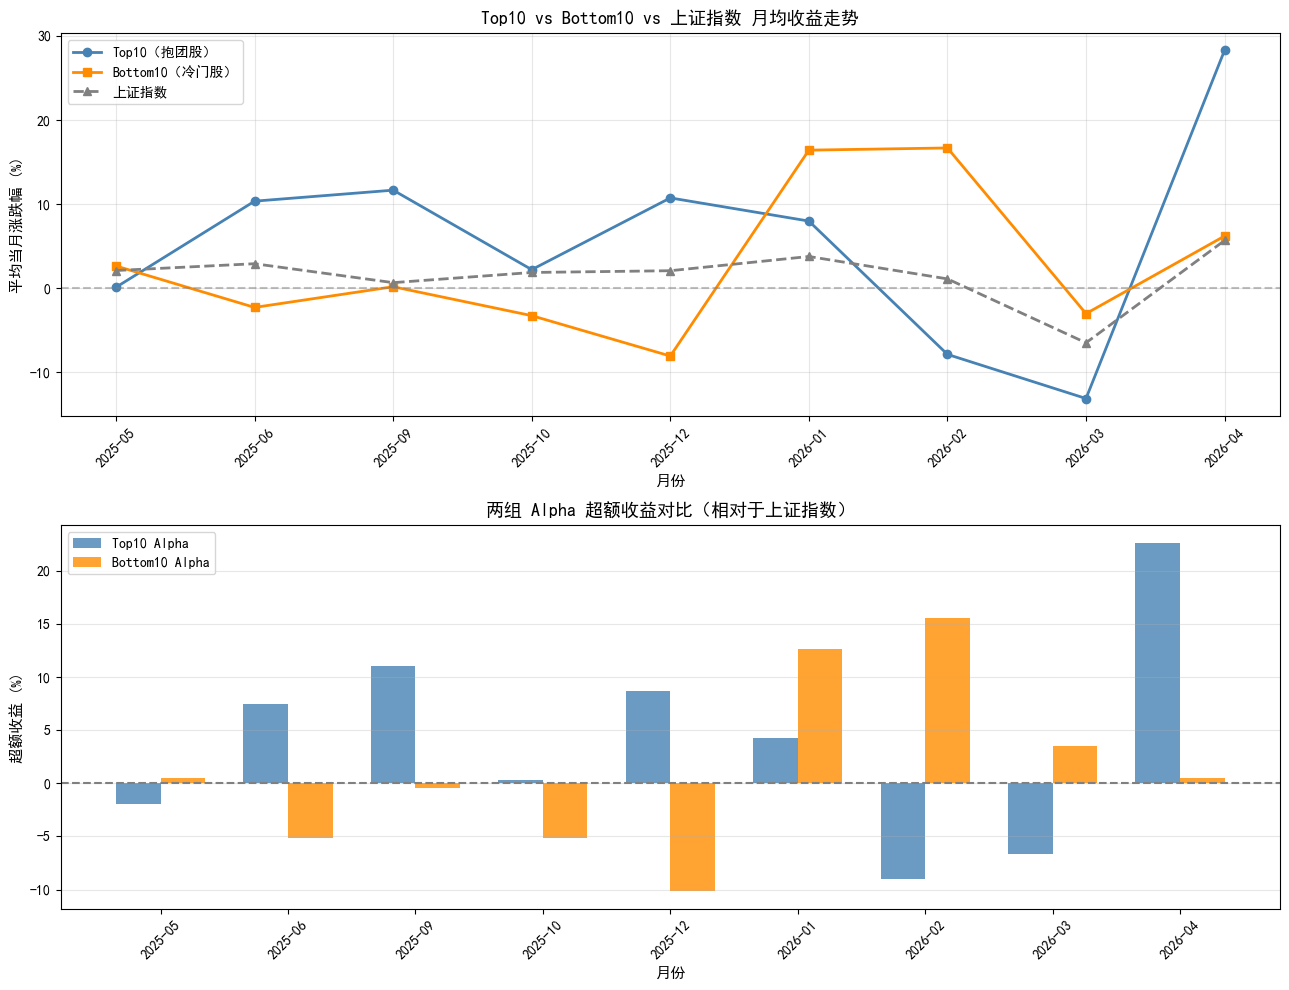


✅ 图表已保存：top10_vs_bottom10_对比图.png


In [279]:
fig, axes = plt.subplots(2, 1, figsize=(13, 10))

# 图1：三组收益走势折线图
axes[0].plot(
    comparison.index, comparison['Top10月均收益(%)'],
    marker='o', label='Top10（抱团股）', linewidth=2, color='steelblue'
)
axes[0].plot(
    comparison.index, comparison['Bottom10月均收益(%)'],
    marker='s', label='Bottom10（冷门股）', linewidth=2, color='darkorange'
)
axes[0].plot(
    comparison.index, comparison['上证月涨跌幅'],
    marker='^', label='上证指数', linewidth=2, color='gray', linestyle='--'
)
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_title('Top10 vs Bottom10 vs 上证指数 月均收益走势', fontsize=13, fontweight='bold')
axes[0].set_xlabel('月份', fontsize=11)
axes[0].set_ylabel('平均当月涨跌幅 (%)', fontsize=11)
axes[0].legend(loc='best')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

# 图2：两组 Alpha 柱状图
x = range(len(comparison))
bar_width = 0.35
months = list(comparison.index)

axes[1].bar(
    [i - bar_width/2 for i in x], comparison['Top10 Alpha(%)'],
    width=bar_width, label='Top10 Alpha', color='steelblue', alpha=0.8
)
axes[1].bar(
    [i + bar_width/2 for i in x], comparison['Bottom10 Alpha(%)'],
    width=bar_width, label='Bottom10 Alpha', color='darkorange', alpha=0.8
)
axes[1].axhline(0, color='gray', linestyle='--')
axes[1].set_title('两组 Alpha 超额收益对比（相对于上证指数）', fontsize=13, fontweight='bold')
axes[1].set_xlabel('月份', fontsize=11)
axes[1].set_ylabel('超额收益 (%)', fontsize=11)
axes[1].set_xticks(x)
axes[1].set_xticklabels(months, rotation=45)
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
output_dir = r'D:\小组作业\维度二\output'
plt.savefig(f'{output_dir}\\top10_vs_bottom10_对比图.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ 图表已保存：top10_vs_bottom10_对比图.png")

### 步骤十：可视化————累计收益曲线

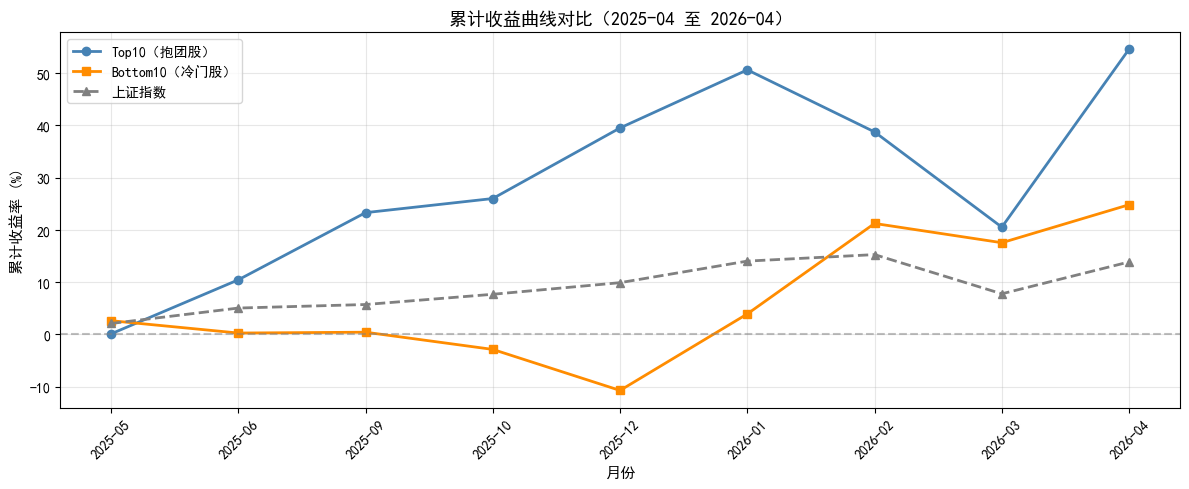


期末累计收益率：
  Top10    累计收益：54.62%
  Bottom10 累计收益：24.83%
  上证指数  累计收益：13.87%

✅ 图表已保存：累计收益曲线.png


In [280]:
cum_top    = (1 + comparison['Top10月均收益(%)']    / 100).cumprod() - 1
cum_bottom = (1 + comparison['Bottom10月均收益(%)'] / 100).cumprod() - 1
cum_index  = (1 + comparison['上证月涨跌幅']         / 100).cumprod() - 1

plt.figure(figsize=(12, 5))
plt.plot(comparison.index, cum_top * 100,    marker='o', label='Top10（抱团股）',    linewidth=2, color='steelblue')
plt.plot(comparison.index, cum_bottom * 100, marker='s', label='Bottom10（冷门股）',  linewidth=2, color='darkorange')
plt.plot(comparison.index, cum_index * 100,  marker='^', label='上证指数',            linewidth=2, color='gray', linestyle='--')
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.title('累计收益曲线对比（2025-04 至 2026-04）', fontsize=13, fontweight='bold')
plt.xlabel('月份', fontsize=11)
plt.ylabel('累计收益率 (%)', fontsize=11)
plt.legend(loc='best')
plt.tick_params(axis='x', rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
output_dir = r'D:\小组作业\维度二\output'
plt.savefig(f'{output_dir}\\累计收益曲线.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n期末累计收益率：")
print(f"  Top10    累计收益：{cum_top.iloc[-1]*100:.2f}%")
print(f"  Bottom10 累计收益：{cum_bottom.iloc[-1]*100:.2f}%")
print(f"  上证指数  累计收益：{cum_index.iloc[-1]*100:.2f}%")
print("\n✅ 图表已保存：累计收益曲线.png")

### 步骤十一：保存明细数据

In [281]:
# 先把累计推荐次数重新合并回来（防止列丢失）
if '累计推荐次数' not in df_top.columns:
    df_top['累计推荐次数'] = df_top['证券代码'].map(
        dict(zip(rec_count['证券代码'], rec_count['累计推荐次数']))
    )
if '累计推荐次数' not in df_bottom.columns:
    df_bottom['累计推荐次数'] = df_bottom['证券代码'].map(
        dict(zip(rec_count['证券代码'], rec_count['累计推荐次数']))
    )

# 明细 DataFrame
df_top_detail = df_top[
    ['证券代码', '证券简称', '机构名称', '推荐月份', '月份',
     '月涨跌幅', '上证月涨跌幅', '累计推荐次数', '分组']
].copy().sort_values(['月份', '累计推荐次数'], ascending=[True, False])

df_bottom_detail = df_bottom[
    ['证券代码', '证券简称', '机构名称', '推荐月份', '月份',
     '月涨跌幅', '上证月涨跌幅', '累计推荐次数', '分组']
].copy().sort_values(['月份', '累计推荐次数'], ascending=[True, True])

# 保存 CSV
df_top_detail.to_csv(f'{data_dir}\\top10_明细.csv',    index=False, encoding='utf-8-sig')
df_bottom_detail.to_csv(f'{data_dir}\\bottom10_明细.csv', index=False, encoding='utf-8-sig')

# 保存 Excel
with pd.ExcelWriter(f'{data_dir}\\top10_vs_bottom10_详细数据.xlsx') as writer:
    comparison.to_excel(writer, sheet_name='月度对比（含Alpha）')
    df_top_detail.to_excel(writer, sheet_name='Top10明细', index=False)
    df_bottom_detail.to_excel(writer, sheet_name='Bottom10明细', index=False)

print("✅ CSV 文件已保存：")
print(f"  - top10_抱团股列表.csv")
print(f"  - bottom10_冷门股列表.csv")
print(f"  - 上证指数月线数据.csv")
print(f"  - top10_bottom10_月线数据.csv")
print(f"  - top10_vs_bottom10_月度对比.csv")
print(f"  - top10_明细.csv")
print(f"  - bottom10_明细.csv")
print(f"\n✅ Excel 文件已保存：")
print(f"  - top10_vs_bottom10_详细数据.xlsx")

✅ CSV 文件已保存：
  - top10_抱团股列表.csv
  - bottom10_冷门股列表.csv
  - 上证指数月线数据.csv
  - top10_bottom10_月线数据.csv
  - top10_vs_bottom10_月度对比.csv
  - top10_明细.csv
  - bottom10_明细.csv

✅ Excel 文件已保存：
  - top10_vs_bottom10_详细数据.xlsx


## 二、分析结论
### 1.整体收益对比

| 指标                     | Top10（抱团股） | Bottom10（冷门股） | 上证指数 |
|--------------------------|----------------|-------------------|----------|
| 13个月累计收益           | 54.5%          | 约 25%            | 约 14%   |
| 年均超额收益（Alpha）    | 显著为正       | 为正但幅度较小    | 基准     |
| 跑赢大盘月份占比         | 多数月份       | 少数月份          | —        |

### 2.核心发现
1. 券商 “抱团股” 推荐具备显著超额收益能力
被多家券商反复推荐的 Top10 标的，累计收益率超 55%，大幅跑赢同期上证指数（约 14%），且多数月份实现了正超额收益，验证了券商持续跟踪标的的长期投资价值。
2. “冷门股” 推荐收益不稳定，参考价值极低
Bottom10 冷门股收益高度依赖少数爆发月份，大部分时间跑输大盘，累计收益仅约 25%，且波动极大，缺乏持续性，噪音特征明显，无法作为可靠投资依据。
3. 市场存在明显的推荐 “马太效应”
推荐次数与收益表现呈正相关：被反复覆盖的抱团股，基本面和市场关注度更高，长期收益能力更强；而单次推荐的冷门股，更多是短期事件驱动或小众题材，难以支撑持续收益。
4. 高收益策略必然伴随高波动风险
抱团股虽收益领先，但波动显著高于大盘，存在阶段性回撤风险；冷门股波动同样大，却无法实现稳定收益，风险收益比远差于抱团股和市场基准。
5. 单次推荐的 “噪音” 远大于持续跟踪的信号价值
冷门股收益的爆发具有偶发性，而抱团股的收益具备更强的持续性和可预测性，说明券商研究的核心价值更多体现在对标的的持续覆盖与跟踪上，而非单次推荐。

## 三、局限性说明
1. 样本选择偏差：仅选取了六大券商的数据，且 Top10/Bottom10 的划分基于推荐次数而非市值、估值等基本面因素，存在选择性偏差。
2. 时间范围有限：研究期仅覆盖 13 个月，无法反映不同市场周期（牛市/熊市）下抱团效应的表现差异。
3. 因果推断局限：本研究仅做描述性统计对比，无法建立因果关系。抱团股跑赢可能是因为优质标的本身被更多机构关注，而非"机构扎堆推荐"这一行为本身带来了收益。